# Определение наилучшей дислокации единственного подразделения (BLP)

## Загрузка исходных данных

In [1]:
import numpy as np
import osmnx as ox
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import genesis as genesis


# Версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\ngenesis:', genesis.__version__,
      )

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.2.2 
genesis: 0.1.030


In [10]:
from genesis.states import get_atm
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS


# 1. Загрузка исходных данных
## Загрузка ГДС
G = ox.load_graphml('data/kemerovo/gds.ml')

## Загрузка границ города
borders = gpd.read_file('data/kemerovo/borders.gpkg')

## Загрузка пожарных подразделений
units = gpd.read_file('data/kemerovo/fire_units.gpkg')
### Сопоставление пожарных подразделений с ближайшими узлами ГДС
units['node'] = ox.distance.nearest_nodes(G, units.geometry.x, units.geometry.y)
### Формирование словаря подразделений для передачи алгоритму
units_dict = {k:v for k,v in zip(units['node'], units['name'])}

## Загрузка зданий
buildings = gpd.read_file('data/kemerovo/buildings.gpkg')
### Сопоставление зданий с ближайшими узлами ГДС
centroids = ox.projection.project_gdf(buildings).geometry.centroid
buildings['node'] = ox.distance.nearest_nodes(ox.project_graph(G), 
                                              centroids.x,
                                              centroids.y
                                              )

## Установка скоростного режима
set_graph_travel_times(
    G,
    speeds=DEFAULT_SPEEDS,
    morph_function = kmh_to_mm)

## Основной способ

Рекомендуемым способом является использование алгоритма жадного добавления **ADD**: `genesis.lscp.LSCP_ADD`.

Данный подход универсален и может быть применен к решению задач **BLP**, **MCLP**, **LSCP**.

Он основан на идее определения точки в при размещении пожарного епо в которой обеспечивается заданное время прибытия к как можно большему количеству объектов защиты. При расчете используется моделирование параметров прибытия подразделений пожарной охраны с использованием матрицы прибытия `genesis.states.ArrivalTimeMatrixState`.

### Расчет матрицы прибытия {.unnumbered}

Матрица прибытия - таблицу в которой строками являются идентификаторы узлов зданий, столбцами - идентификаторы узлов графа из которых можно попасть в каждое из зданий, в ячейках хранится числовое значение времени прибытия из каждого узла графа к каждому из зданий, либо значение `NaN`, означающее, что из узла $N_n$ нельзя попасть к зданию $B_n$, за заданное время (@tbl-atm-example-2).

|  | $N_1$ | $N_2$ | $N_3$ | $N_4$ | $N_5$ |
| - | ---- | ----- | ----- | --- | ----- |
| $B_1$ | 3,1 | 4,2 | 1,5 | 13,2 | 7,5 |
| $B_2$ | 6,6 | `NaN` | 14,2 | 7,2 | 3,3 |
| $B_3$ | 4,2 | 6,1 | `NaN` | 6,4 | 12,3 |
| $B_4$ | `NaN` | 12,9 | 4,5 | `NaN` | `NaN` |
| $B_5$ | 6,3 | `NaN` | `NaN` | `NaN` | 2,1 |
: Пример матрицы прибытия {#tbl-atm-example-2}

В приведенном примере (@tbl-atm-example-2) можно заметить, что узлом из которого можно попасть за 10 минут в наибольшее количество зданий является узел $N_1$ (4 здания) - этот узел и является предпочтительным для размещения пожарного депо.

Матрица рассчитывается при помощи функции `genesis.states.get_atm`:

#### Расчет для ограниченного размера выборки зданий {.unnumbered}

Ограничивать размер выборки рекомендуется для ускорения расчетов. При указании аргумента `data_sample_size` расчет будет произведен для указанного числа случайным образом выбранных объектов из `data`. 

Следует соблюдать разумный баланс между временем расчета и точностью -> чем больше доля используемых в расчете объектов, тем выше точность, но больше требуется времени, и наоборот.

In [ ]:
matrix = get_atm(G, 
                 data             = buildings,
                 data_sample_size = 500,       # Размер выборки (чем меньше, тем быстрее расчет, но ниже точность)
                 )
print('Размер матрицы:', matrix.shape)
matrix

|########################################| 100.0%


,390613258,390613261,390613268,390613272,390613275,390613276,390613278,390613280,390613285,390613288,...,12829481034,12829481035,12829481036,12829481037,12829481038,12829481039,12829481040,12829481041,12829481042,12829481043
1025674499,16.499098,18.557650,19.097509,18.662916,19.576539,12.007233,19.350571,13.890795,18.896191,18.435151,...,17.683017,18.104929,18.938273,18.824924,18.674029,18.301474,18.453541,18.223924,18.372584,17.618242
1156562208,7.222606,2.103280,2.643139,4.297942,1.084390,8.904044,6.839153,8.143145,1.764739,7.397502,...,9.279301,9.701213,9.816437,9.703088,9.552192,9.897758,10.049825,9.820208,9.968868,9.214526
11645167573,15.924529,18.222305,18.762164,18.088347,19.241195,13.804143,19.270145,13.316225,18.560846,18.354726,...,20.271432,20.693344,21.526688,21.413339,21.262443,20.889888,21.041955,20.812338,20.960998,20.206656
1025676270,13.018914,14.277285,14.817144,16.471947,15.296174,12.825102,11.871625,14.246049,14.615825,10.803719,...,9.030858,9.452771,10.286114,10.172766,10.021870,9.649315,9.801382,9.571765,9.720425,8.966083
1025674564,19.092438,21.150990,21.690849,21.256257,22.169880,14.600574,21.943911,16.484135,21.489531,21.028492,...,21.287374,21.709287,22.542630,22.429282,22.278386,21.905831,22.057898,21.828281,21.976941,21.222599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390616885,15.875873,10.756546,11.296405,8.561883,11.775435,16.675330,15.492419,13.052117,11.095087,16.050768,...,16.190700,16.612612,16.660490,16.547141,16.396245,16.809157,16.961224,16.731607,16.880267,16.125925
1136437809,22.446568,24.505120,25.044979,24.610386,25.524009,17.954703,24.495036,19.838265,24.843661,23.427130,...,21.654269,22.076181,22.909525,22.796176,22.645280,22.272726,22.424793,22.195176,22.343835,21.589494
7015926847,20.998162,23.056714,23.596574,23.161981,24.075604,16.506298,21.828851,18.389859,23.395255,20.760944,...,18.988084,19.409996,20.243340,20.129991,19.979095,19.606540,19.758608,19.528990,19.677650,18.923308
1120348614,11.425219,10.899094,11.438954,10.739421,11.917984,11.679886,13.253749,8.056673,11.237635,13.812098,...,15.693897,16.115810,16.231033,16.117684,15.966788,16.312354,16.464421,16.234804,16.383464,15.629122


#### Расчет с ограничением времени прибытия {.unnumbered}

При установлении ограничения по времени прибытия расчет выполняется заметно быстрее, т.к. время прибытия вычисляется только для зон ограниченных заданным временем (в минутах).

In [ ]:
matrix = get_atm(G, 
                 data             = buildings,
                 cutoff           = 10,         # Ограничение по времени прибытия в минутах (сокращает время расчета)
                 )
print('Размер матрицы:', matrix.shape)

|########################################| 100.0%
Размер матрицы: (15459, 23415)


#### Расчет с ограничением по времени определенным для каждого здания {.unnumbered}

In [ ]:
matrix = get_atm(G, 
                 data              = buildings,
                 data_cutoff_field = 'need_time',
                 )
print('Размер матрицы:', matrix.shape)

### Расчет без учета имеющихся подразделений {.unnumbered}

|########################################| 100.0%


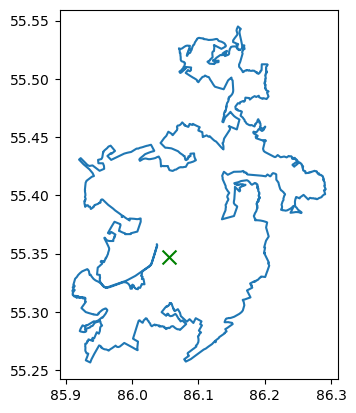

In [ ]:
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState, ArrivalTimeMatrixState
from fire_units.metrics import CoverIndexBuilding, ArrivalTimeBuilding


# 2. Сборка решения
## Расчет матрицы прибытия
matrix = get_atm(G, 
                 data             = buildings,
                 cutoff           = 10,
                 )

## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = state,                                    # Алгоритм моделирования параметров прибытия
    matrix              = matrix,
    metric_function     = CoverIndexBuilding(buildings, ip_val=10), # Используется метрика ИП-10
    stop_case_function  = lambda dynamic_nodes, **kwargs: len(dynamic_nodes) >= 1,      # Расчет проводится для 1 подразделения
)


# 3. Расчет BLP
best_nodes, best_metric = add(
        env          = G,
    )


# 4. Печать результатов
## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
ax = borders.boundary.plot()
g_nodes.loc[best_nodes.keys()].plot(ax=ax, color='green', marker='x', markersize=100)
ax.set_axis_off()
plt.show()

:::{.callout-warning}
### Важно 

Алгоритм моделирования `ArrivalTimeMatrixState(matrix)` используется в `LSCP_ADD` только в том случае, если при расчете матрицы прибытия **не было указано** ограничение времени прибытия `cutoff`.

Если же в функции `get_atm` **было указано** ограничение времени прибытия `cutoff` (так как в примере выше), то следует использовать алгоритм моделирования `FirstArrivalUnitState()`

:::

## Дополнительные способы